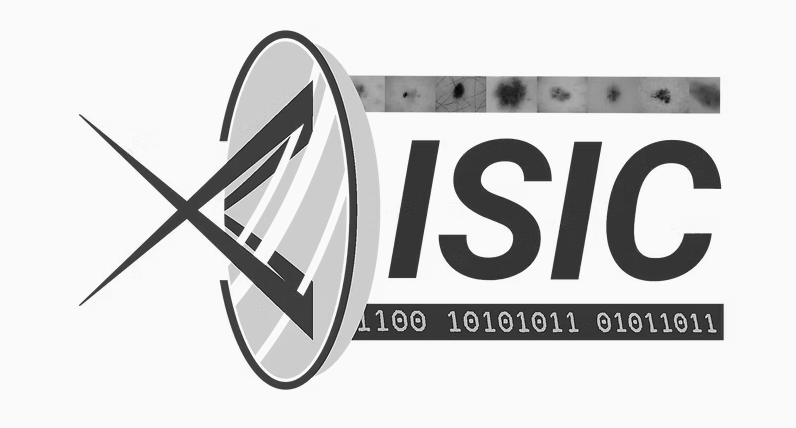

# **ISIC Melanoma Image Segmentation**

In [1]:
import cv2
import numpy as np
from tqdm import tqdm
import PIL.Image as Image
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import albumentations as A
import yaml

/home/ruiz/miniconda3/envs/vpc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Visualize samples

In [2]:
def resolve_data_root():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "isic_segmentation",
        cwd / "Image Segmentation 4p" / "isic_segmentation",
    ]
    for candidate in candidates:
        if (candidate / "isic_segmentation.yml").exists():
            return candidate
    raise FileNotFoundError("Could not find isic_segmentation.yml in the expected notebook-relative locations.")

DATA_ROOT = resolve_data_root()
DATASET_YAML = DATA_ROOT / "isic_segmentation.yml"

with DATASET_YAML.open("r", encoding="utf-8") as f:
    dataset_spec = yaml.safe_load(f)

def build_split_paths(indices):
    image_paths = [str(DATA_ROOT / dataset_spec["images"][idx]["location"]) for idx in indices]
    mask_paths = [str(DATA_ROOT / dataset_spec["images"][idx]["label"]) for idx in indices]
    return image_paths, mask_paths

training_indices = dataset_spec["split"]["training"]
validation_indices = dataset_spec["split"]["validation"]
test_indices = dataset_spec["split"]["test"]

sample_entry = dataset_spec["images"][training_indices[0]]
mask_sample_path = str(DATA_ROOT / sample_entry["label"])
image_sample_path = str(DATA_ROOT / sample_entry["location"])

mask_sample = cv2.imread(mask_sample_path, cv2.IMREAD_GRAYSCALE)
image_sample = cv2.imread(image_sample_path)
image_sample = cv2.cvtColor(image_sample, cv2.COLOR_BGR2RGB)

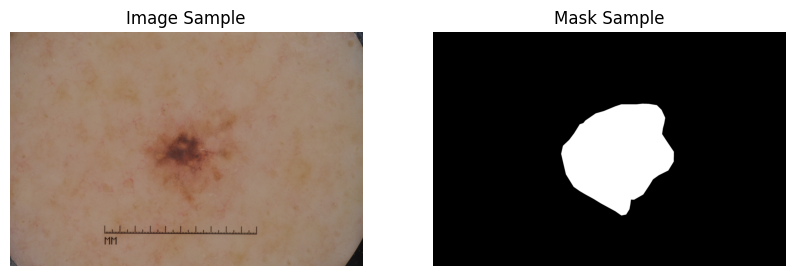

In [3]:
image_sample = Image.open(image_sample_path).convert("RGB")
mask_sample = Image.open(mask_sample_path).convert("L")

#show the image and mask samples
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Image Sample")
plt.imshow(image_sample)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Mask Sample")
plt.imshow(mask_sample, cmap="gray")
plt.axis("off")
plt.show()

## 1. Create the Dataset class

The implementation relies on the following directory structure:
```
├── Image_Segmentation.ipynb
├── isic_segmentation
│   ├── ground_truth
│   │   ├── ISIC_0000000_segmentation.png
│   │   ├── ISIC_0000001_segmentation.png
│   │   ├── ...
│   ├── images_segmentation
│   │   ├── ISIC_0000000.jpg
│   │   ├── ISIC_0000001.jpg
│   │   ├── ...
```

In [4]:
class ISICDataset(Dataset):
    
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = self.load_image(self.image_paths[idx])
        mask = self.load_mask(self.mask_paths[idx])

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

    def load_image(self, path):
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    def load_mask(self, path):
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        return mask


In [5]:
train_image_paths, train_mask_paths = build_split_paths(training_indices)
val_image_paths, val_mask_paths = build_split_paths(validation_indices)
test_image_paths, test_mask_paths = build_split_paths(test_indices)

print(f"Loaded YAML splits from {DATASET_YAML}")
print(f"Training images: {len(train_image_paths)}")
print(f"Validation images: {len(val_image_paths)}")
print(f"Test images: {len(test_image_paths)}")

Loaded YAML splits from /home/ruiz/Repositories/VPC/Image Segmentation 4p/isic_segmentation/isic_segmentation.yml
Training images: 2000
Validation images: 150
Test images: 600


## 2. Use the YAML-defined splits and define the U-Net


In [6]:
SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 8e-4
NUM_WORKERS = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

class AlbumentationsTransform:
    def __init__(self, image_size=IMAGE_SIZE, augment=False):
        resize_h, resize_w = image_size
        if augment:
            self.transform = A.Compose([
                A.Resize(height=resize_h, width=resize_w),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.5),
                A.OneOf([
                    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
                    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                ], p=0.35),
            ])
        else:
            self.transform = A.Compose([
                A.Resize(height=resize_h, width=resize_w),
            ])

    def __call__(self, image, mask):
        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"]

        image = torch.from_numpy(image.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask = torch.from_numpy((mask > 0).astype(np.float32)).unsqueeze(0)

        return {"image": image, "mask": mask}

train_transform = AlbumentationsTransform(image_size=IMAGE_SIZE, augment=True)
val_transform = AlbumentationsTransform(image_size=IMAGE_SIZE, augment=False)
test_transform = AlbumentationsTransform(image_size=IMAGE_SIZE, augment=False)

train_dataset = ISICDataset(train_image_paths, train_mask_paths, transform=train_transform)
val_dataset = ISICDataset(val_image_paths, val_mask_paths, transform=val_transform)
test_dataset = ISICDataset(test_image_paths, test_mask_paths, transform=test_transform)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}

if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Using device: {DEVICE}")
print(f"Workers: {NUM_WORKERS}")
print(f"Pin memory: {loader_kwargs['pin_memory']}")
print("Albumentations medical-image augmentation enabled for train split.")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        up_channels = features[-1] * 2
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(up_channels, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))
            up_channels = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)


model = UNet().to(DEVICE)
model


Using device: cuda
Workers: 16
Pin memory: True
Albumentations medical-image augmentation enabled for train split.
Train samples: 2000
Validation samples: 150
Test samples: 600


UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (downs): ModuleList(
    (0): DoubleConv(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=

## 3. Train and validate the model


In [7]:
def segmentation_metrics(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    tp = (preds * targets).sum(dim=1)
    fp = (preds * (1 - targets)).sum(dim=1)
    fn = ((1 - preds) * targets).sum(dim=1)
    tn = ((1 - preds) * (1 - targets)).sum(dim=1)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)

    return {
        "dice": dice.mean(),
        "iou": iou.mean(),
        "precision": precision.mean(),
        "recall": recall.mean(),
        "accuracy": accuracy.mean(),
    }


def run_epoch(loader, model, criterion, optimizer=None, scaler=None, epoch_idx=0):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    tracked_metrics = ["loss", "dice", "iou", "precision", "recall", "accuracy"]
    totals = {name: torch.zeros(1, device=DEVICE) for name in tracked_metrics}

    mode = "Train" if is_training else "Val"
    pbar = tqdm(loader, total=len(loader), desc=f"Epoch {epoch_idx} [{mode}]", leave=False)

    with torch.set_grad_enabled(is_training):
        for step, (images, masks) in enumerate(pbar, start=1):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                logits = model(images)
                loss = criterion(logits, masks)

            if is_training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            batch_metrics = segmentation_metrics(logits.detach(), masks)
            totals["loss"] += loss.detach().float()
            for name, value in batch_metrics.items():
                totals[name] += value.float()

            if step % 20 == 0 or step == len(loader):
                pbar.set_postfix({
                    "loss": f"{(totals['loss'] / step).item():.4f}",
                    "dice": f"{(totals['dice'] / step).item():.4f}",
                    "iou": f"{(totals['iou'] / step).item():.4f}",
                })

    return {name: (value / len(loader)).item() for name, value in totals.items()}


criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    threshold=1e-4,
    min_lr=1e-6,
)
history = {
    "train_loss": [], "train_dice": [], "train_iou": [], "train_precision": [], "train_recall": [], "train_accuracy": [],
    "val_loss": [], "val_dice": [], "val_iou": [], "val_precision": [], "val_recall": [], "val_accuracy": [],
    "lr": []
}

for epoch in range(NUM_EPOCHS):
    train_metrics = run_epoch(train_loader, model, criterion, optimizer, scaler, epoch + 1)
    val_metrics = run_epoch(val_loader, model, criterion, epoch_idx=epoch + 1)
    scheduler.step(val_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    for name, value in train_metrics.items():
        history[f"train_{name}"].append(value)
    for name, value in val_metrics.items():
        history[f"val_{name}"].append(value)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"train_loss: {train_metrics['loss']:.4f} | train_dice: {train_metrics['dice']:.4f} | train_iou: {train_metrics['iou']:.4f} | "
        f"val_loss: {val_metrics['loss']:.4f} | val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | "
        f"lr: {current_lr:.6f}"
    )

test_metrics = run_epoch(test_loader, model, criterion, epoch_idx=NUM_EPOCHS + 1)
print(
    f"Test set | "
    f"test_loss: {test_metrics['loss']:.4f} | test_dice: {test_metrics['dice']:.4f} | test_iou: {test_metrics['iou']:.4f} | "
    f"test_precision: {test_metrics['precision']:.4f} | test_recall: {test_metrics['recall']:.4f} | test_accuracy: {test_metrics['accuracy']:.4f}"
)


Epoch 01/40 | train_loss: 0.3729 | train_dice: 0.5973 | train_iou: 0.4884 | val_loss: 0.3649 | val_dice: 0.5747 | val_iou: 0.4692 | lr: 0.000800


Epoch 02/40 | train_loss: 0.2576 | train_dice: 0.6806 | train_iou: 0.5804 | val_loss: 0.3401 | val_dice: 0.5644 | val_iou: 0.4649 | lr: 0.000800


Epoch 03/40 | train_loss: 0.2267 | train_dice: 0.7222 | train_iou: 0.6245 | val_loss: 0.2861 | val_dice: 0.6342 | val_iou: 0.5263 | lr: 0.000800


Epoch 04/40 | train_loss: 0.1960 | train_dice: 0.7567 | train_iou: 0.6604 | val_loss: 0.2508 | val_dice: 0.6683 | val_iou: 0.5509 | lr: 0.000800


Epoch 05/40 | train_loss: 0.1789 | train_dice: 0.7672 | train_iou: 0.6743 | val_loss: 0.2279 | val_dice: 0.6948 | val_iou: 0.5910 | lr: 0.000800


...

Epoch 37/40 | train_loss: 0.1055 | train_dice: 0.8607 | train_iou: 0.7822 | val_loss: 0.1875 | val_dice: 0.7842 | val_iou: 0.6938 | lr: 0.000050


Epoch 38/40 | train_loss: 0.1045 | train_dice: 0.8599 | train_iou: 0.7816 | val_loss: 0.1718 | val_dice: 0.7880 | val_iou: 0.6973 | lr: 0.000050


Epoch 39/40 | train_loss: 0.1066 | train_dice: 0.8599 | train_iou: 0.7803 | val_loss: 0.1806 | val_dice: 0.7909 | val_iou: 0.6992 | lr: 0.000050


Epoch 40/40 | train_loss: 0.1041 | train_dice: 0.8630 | train_iou: 0.7842 | val_loss: 0.1832 | val_dice: 0.7860 | val_iou: 0.6955 | lr: 0.000050


Test set | test_loss: 0.2353 | test_dice: 0.7872 | test_iou: 0.6926 | test_precision: 0.9175 | test_recall: 0.7484 | test_accuracy: 0.9137
